# Autoencoders — TensorFlow / Keras (CPU)

## Model: Dense Autoencoder + Convolutional Denoising Autoencoder
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 3,072 features (32×32×3 RGB)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Keras Functional API conv denoising AE — architecture sweep + noise type comparison (Gaussian vs salt-and-pepper)

## CPU Strategy
- TF 2.11+ dropped native Windows GPU support — all ops run on CPU
- Keras Sequential API for dense AE baseline
- Keras Functional API for conv AE — enables separate encoder/decoder models
- Built-in `model.fit()` with validation_split, EarlyStopping callback

## Evaluation Strategy
- **Metrics**: Reconstruction MSE/MAE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids (RGB), training loss curves, latent space t-SNE

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline, match SK/PT)
3. Training history + reconstruction visualization
4. Conv denoising AE — architecture sweep + noise type comparison (showcase)
5. Dense vs best conv denoising comparison
6. Latent space + downstream classification
7. Performance benchmarks
8. Save results

In [ ]:
# Step 1: Setup
"""
TensorFlow Autoencoder — CPU only (TF 2.11+ dropped Windows GPU)
Using 15K training subset — TF CPU cannot handle full 50K color images
with conv model gradients without OOM crashing the system
"""

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Prevent oneDNN access violations
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # Suppress TF warnings

import numpy as np
import tensorflow as tf
from tensorflow import keras
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072
LATENT_DIM = 128
BATCH_SIZE = 128
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load preprocessed data
X_train_full, X_test_flat, y_train_full, y_test, metadata = load_processed_data('autoencoder')
X_train_img_full = np.load('../../data/processed/autoencoder/X_train_img.npy')
X_test_img = np.load('../../data/processed/autoencoder/X_test_img.npy')

# 15K subset — TF CPU crashed on 50K with conv models
TF_SUBSET = 15000
rng = np.random.RandomState(RANDOM_STATE)
subset_idx = rng.choice(len(X_train_full), TF_SUBSET, replace=False)
X_train_flat = X_train_full[subset_idx]
X_train_img = X_train_img_full[subset_idx]
y_train = y_train_full[subset_idx]

# Free full arrays immediately
del X_train_full, X_train_img_full, y_train_full

print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: CPU (TF 2.11+ dropped native Windows GPU)")
print(f"TF version: {tf.__version__}")
print(f"Train flat: {X_train_flat.shape} | Test flat: {X_test_flat.shape}")
print(f"Train img:  {X_train_img.shape} | Test img:  {X_test_img.shape}")
print(f"Subset: {TF_SUBSET:,} / 50,000 (CPU memory constraint)")
print(f"Classes: {len(CLASS_NAMES)}")
print(f"Pixel range: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
print(f"Dtype: {X_train_flat.dtype}")

[1/8] TensorFlow — Autoencoder Pipeline
Device: CPU (TF 2.11+ dropped native Windows GPU)
TF version: 2.20.0
Train flat: (15000, 3072) | Test flat: (10000, 3072)
Train img:  (15000, 32, 32, 3) | Test img:  (10000, 32, 32, 3)
Subset: 15,000 / 50,000 (CPU memory constraint)
Classes: 10
Pixel range: [0.0, 1.0]
Dtype: float32


In [2]:
# Step 2: Simple Dense Autoencoder (Baseline)

"""
Keras Sequential: 3072 → 512 → 128 → 512 → 3072
Sigmoid output maps to [0,1] pixel space
"""

print("=" * 60)
print("[2/8] Simple Dense Autoencoder — Baseline")
print("=" * 60)

dense_ae = keras.Sequential([
    keras.layers.Input(shape=(N_FEATURES,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(LATENT_DIM, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(N_FEATURES, activation='sigmoid')
])

dense_ae.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

with track_performance() as perf:
    history = dense_ae.fit(
        X_train_flat, X_train_flat,
        epochs=200,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

X_test_recon = dense_ae.predict(X_test_flat, verbose=0)

baseline_mse = float(np.mean((X_test_flat - X_test_recon) ** 2))
baseline_mae = float(np.mean(np.abs(X_test_flat - X_test_recon)))
n_params = dense_ae.count_params()
best_epoch = len(history.history['loss']) - 15

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {len(history.history['loss'])} (early stopped ~epoch {best_epoch})")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"Peak memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")
print(f"\nParameters: {n_params:,}")
print(f"\nSK baseline: MSE 0.0133 | PT baseline: MSE 0.0091")


[2/8] Simple Dense Autoencoder — Baseline

Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 137 (early stopped ~epoch 122)
Best val loss: 0.009683
Training time: 244.97s
Peak memory: 380.19 MB

Reconstruction Quality (test set):
  MSE:  0.009634
  MAE:  0.071917
  RMSE: 0.098154

Parameters: 3,281,024

SK baseline: MSE 0.0133 | PT baseline: MSE 0.0091


[3/8] Visualizations


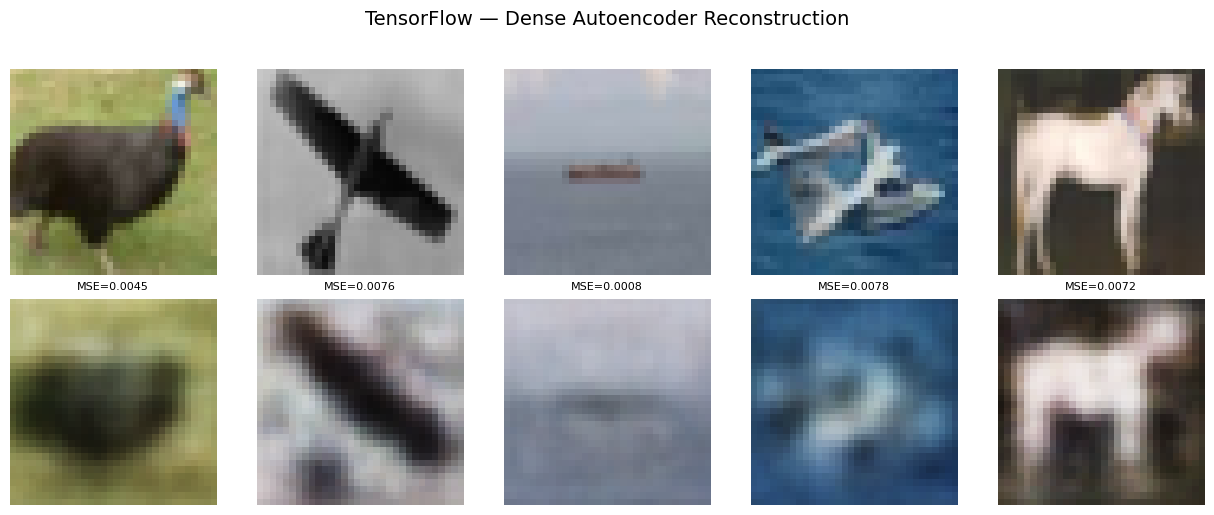

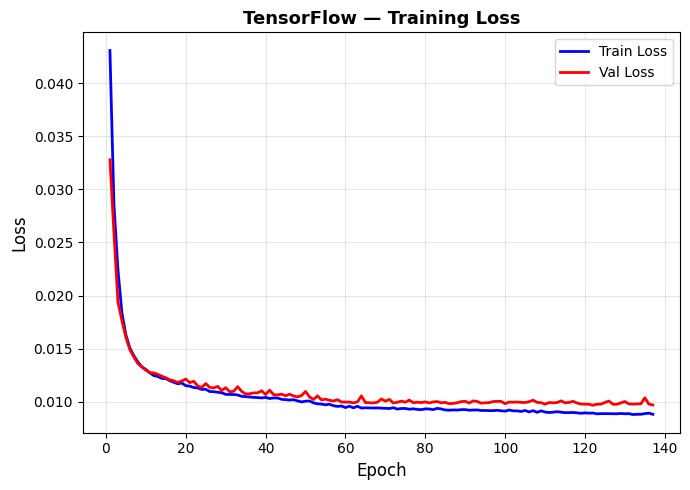


Training: 137 epochs
Final train loss: 0.008828
Best val loss:    0.009683


In [3]:
# Step 3: Visualizations

# Reconstruction grid (RGB) + training loss curve


print("=" * 60)
print("[3/8] Visualizations")
print("=" * 60)

rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test_flat), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_dense.png'
)

train_history = {
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

plot_training_history(
    history=train_history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_dense.png'
)

print(f"\nTraining: {len(history.history['loss'])} epochs")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Best val loss:    {min(history.history['val_loss']):.6f}")
